In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("netflix_cleaned.csv")

In [3]:
df.head()

,Show_ID,Type,Title,Director,Cast,Country,Date_Added,Release_Year,Rating,Duration,Genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Specified,United States,25-Sep-21,2020,PG-13,90 min,Documentaries
1,s2,Tv Show,Blood & Water,Not Specified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Specified,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,Tv Show,Jailbirds New Orleans,Not Specified,Not Specified,Not Specified,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,Tv Show,Kota Factory,Not Specified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [4]:
df["Release_Year"].dtype

dtype('int64')

In [5]:
df["Release_Year"].isna().sum()

np.int64(0)

In [6]:
df["Release_Year"].nunique()

74

In [8]:
df["Release_Year"].sort_values().unique()

array([1925, 1942, 1943, 1944, 1945, 1946, 1947, 1954, 1955, 1956, 1958,
       1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969,
       1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980,
       1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021])

In [9]:
# Calculating yearly content releases
yearly_releases = df.groupby("Release_Year").size().reset_index(name="content_count")

In [11]:
yearly_releases.head(10)

,Release_Year,content_count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4
5,1946,2
6,1947,1
7,1954,2
8,1955,3
9,1956,2


In [12]:
# Identifying years with the most releases
yearly_releases.sort_values("content_count", ascending=False).head(10)

,Release_Year,content_count
70,2018,1147
69,2017,1032
71,2019,1030
72,2020,953
68,2016,902
73,2021,592
67,2015,560
66,2014,352
65,2013,288
64,2012,237


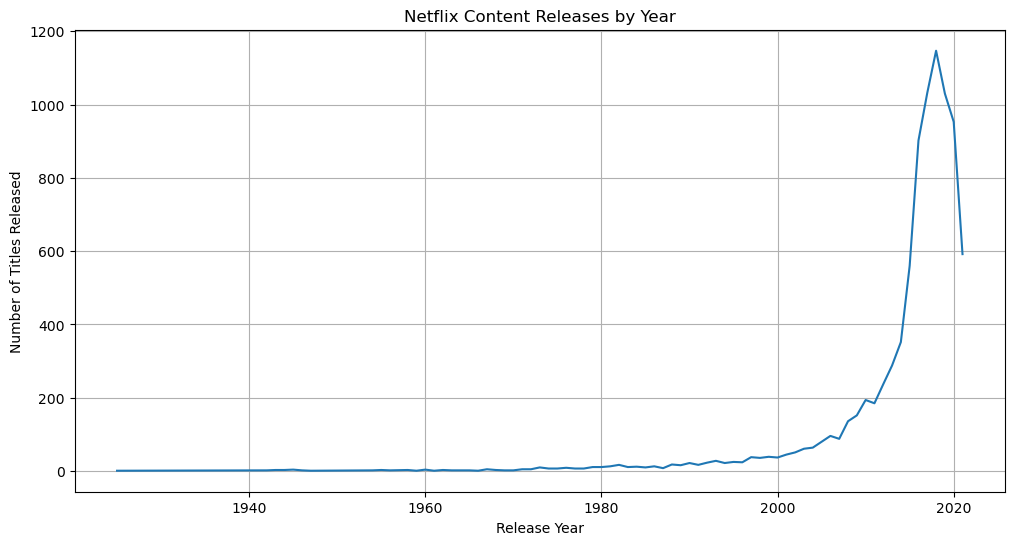

In [14]:
# Visualization 1: Netflix Content Releases by Year
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_releases["Release_Year"],
    yearly_releases["content_count"]
)

plt.title("Netflix Content Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles Released")
plt.grid(True)

plt.show()

In [22]:
recent_releases = yearly_releases[
    yearly_releases["Release_Year"] >= 2000
].copy()

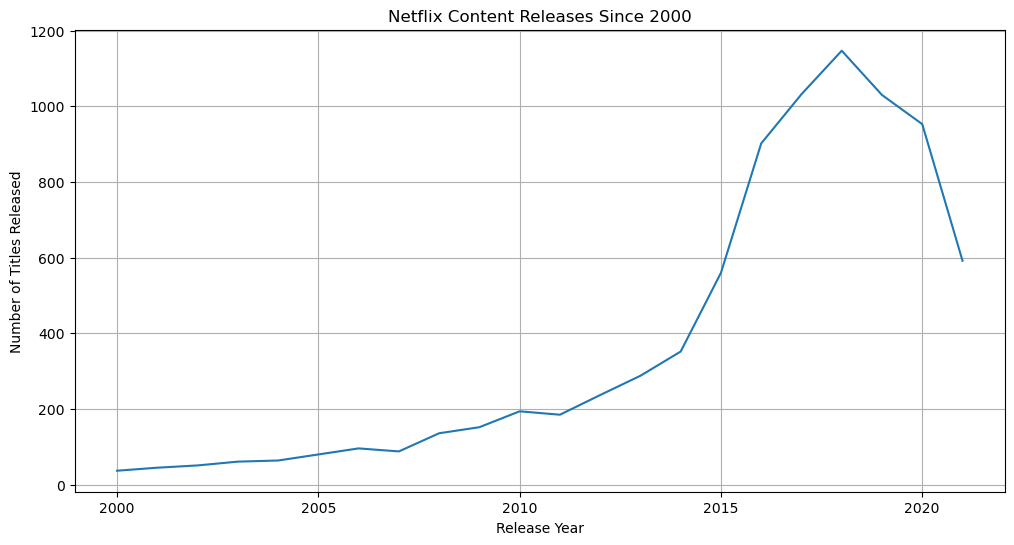

In [17]:
# Visualization 2: Recent Netflix Content Releases 
plt.figure(figsize=(12, 6))

plt.plot(
    recent_releases["Release_Year"],
    recent_releases["content_count"]
)

plt.title("Netflix Content Releases Since 2000")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles Released")
plt.grid(True)

plt.show()

In [23]:
# Calculating Year over Year change - Trend Analysis
recent_releases["yearly_change"] = recent_releases["content_count"].diff()

In [24]:
recent_releases.head()

,Release_Year,content_count,yearly_change
52,2000,37,NaN
53,2001,45,8.0
54,2002,51,6.0
55,2003,61,10.0
56,2004,64,3.0


In [25]:
# Calculating percentage growth
recent_releases["growth_rate"] = recent_releases["content_count"].pct_change() * 100

In [26]:
recent_releases.tail(10)

,Release_Year,content_count,yearly_change,growth_rate
64,2012,237,52.0,28.108108
65,2013,288,51.0,21.518987
66,2014,352,64.0,22.222222
67,2015,560,208.0,59.090909
68,2016,902,342.0,61.071429
69,2017,1032,130.0,14.412417
70,2018,1147,115.0,11.143411
71,2019,1030,-117.0,-10.200523
72,2020,953,-77.0,-7.475728
73,2021,592,-361.0,-37.880378


## Business Insights
- Netflix content production increased significantly over time: The number of titles released each year shows a clear upward trend, particularly from around 2010 onwards. This indicates a major expansion in Netflix's content library over the period analyzed.
  
- Content production accelerated rapidly between 2014 and 2018: Releases increased from 352 titles in 2014 to 1,147 titles in 2018. This sharp increase suggests that Netflix significantly expanded its investment in original and acquired content during this period.

- 2018 was the peak release year in the dataset: Netflix recorded 1,147 titles released in 2018, the highest annual total among the years analyzed. Production remained relatively high in 2019 and 2020, with 1,030 and 953 titles respectively.

- Content releases declined after the 2018 peak: After reaching the peak in 2018, releases decreased to 1,030 in 2019, 953 in 2020, and 592 in 2021. This indicates a notable slowdown in content additions toward the end of the dataset.

- The long term trend reflects Netflix's growing emphasis on content expansion: The relatively low number of releases in the early years compared with the substantial increase in later years demonstrates how Netflix's content library expanded considerably over time.